In [20]:
import sqlite3
import pandas as pd
import numpy as np

conn = sqlite3.connect("../fraud.db")
df = pd.read_sql("""
    SELECT * 
    FROM transactions
""", conn)

def run_query(query):
    return pd.read_sql(query, conn)

In [21]:
amounts = run_query("""
    SELECT Class,
    AVG(Amount) AS mean_amount,
    SUM((Amount - mean_amount) * (Amount - mean_amount)) / (COUNT(*) - 1) AS Variance
    FROM (
        SELECT 
            Class,
            Amount,
            AVG(Amount) OVER (PARTITION BY Class) AS mean_amount
        FROM transactions
    )
    GROUP BY Class;
""")

amounts["StdDev"] = np.sqrt(amounts["Variance"])
amounts

,Class,mean_amount,Variance,StdDev
0,0,88.291022,62552.557157,250.105092
1,1,122.211321,65886.310491,256.683288


## IQR

In [23]:
q1 = df["Amount"].quantile(0.25)
q3 = df["Amount"].quantile(0.75)

iqr = q3 - q1
iqr

71.565

In [35]:
lower_bound = q1 - 1.5 * iqr
upper_bound = q3 + 1.5 * iqr

outliers = df[(df["Amount"] < lower_bound) | (df["Amount"] > upper_bound)]

## Skewness

In [36]:
df.groupby("Class")["Amount"].skew()

Class
0    17.003147
1     3.754477
Name: Amount, dtype: float64

In [37]:
def iqr(series):
    return series.quantile(0.75) - series.quantile(0.25)

summary = df.groupby("Class")["Amount"].agg([
    "mean",
    "median",
    "std",
    "skew",
    iqr
])

summary

,mean,median,std,skew,iqr
Class,,,,,
0,88.291022,22.00,250.105092,17.003147,71.40
1,122.211321,9.25,256.683288,3.754477,104.89


## Basic Statistical Summary

Normal transactions exhibit lower variance and a tighter interquartile range, indicating more stable and predictable spending behavior. Fraudulent transactions appear more dispersed across the feature space, suggesting less consistent structure.

Due to the extreme class imbalance, differences in skewness should be interpreted cautiously, as they may be influenced by sample size effects and outliers rather than true behavioral differences.

In the next section, we will explore the PCA-transformed features to assess whether fraudulent transactions exhibit greater dispersion in feature space and whether any components show stronger class separability.

### PCA Analysis
We'll start with a filtering process. This process will tell us which features are highly corrolated with the fraudulent activities, so we can start to focus our machine learning algorithms later on those features. This will also increase the speed of our plotting to show the distinction between normal transactions and fraudulent transactions.

In [43]:
def effect_size(feature):
    fraud = df[df["Class"] == 1][feature]
    normal = df[df["Class"] == 0][feature]

    return abs(fraud.mean() - normal.mean()) / df[feature].std()

scores = {col: effect_size(col) for col in df.columns if col not in ["Class", "Time"]}
scores

{'V1': 2.440504630453812,
 'V2': 2.1982862588576855,
 'V3': 4.6466141523485796,
 'V4': 3.2134966851943934,
 'V5': 2.287038921370669,
 'V6': 1.0509538710197754,
 'V7': 4.509252688613893,
 'V8': 0.4786050799310727,
 'V9': 2.353462561083453,
 'V10': 5.222673278516475,
 'V11': 3.7294997832379697,
 'V12': 6.275236228715755,
 'V13': 0.11004305467275398,
 'V14': 7.285436324013336,
 'V15': 0.10170209698587061,
 'V16': 4.732777296736983,
 'V17': 7.861862796631349,
 'V18': 2.6846327639237004,
 'V19': 0.8375961229702319,
 'V20': 0.48378723369755866,
 'V21': 0.9731788008130012,
 'V22': 0.019392535646349296,
 'V23': 0.06466018441945165,
 'V24': 0.17388382838664296,
 'V25': 0.07965156386298859,
 'V26': 0.10728868339981255,
 'V27': 0.42333055388125684,
 'V28': 0.22963366892741272,
 'Amount': 0.13561603990555074}

In [44]:
sorted(scores.items(), key=lambda x: x[1], reverse=True)[:10]

[('V17', 7.861862796631349),
 ('V14', 7.285436324013336),
 ('V12', 6.275236228715755),
 ('V10', 5.222673278516475),
 ('V16', 4.732777296736983),
 ('V3', 4.6466141523485796),
 ('V7', 4.509252688613893),
 ('V11', 3.7294997832379697),
 ('V4', 3.2134966851943934),
 ('V18', 2.6846327639237004)]

In [47]:
df.corr()["Class"].sort_values(ascending=True)[:10]

V17   -0.326481
V14   -0.302544
V12   -0.260593
V10   -0.216883
V16   -0.196539
V3    -0.192961
V7    -0.187257
V18   -0.111485
V1    -0.101347
V9    -0.097733
Name: Class, dtype: float64

### Visualization of Top Features
We saw in the previous section that the top 5 features for potential fraud detection include: V17, V14, V12, V10, and V16. We'll now take a closer inspection of these 5 featues through histograms and boxplots to uncover any hidden information about them

In [50]:
fraud = df[df["Class"] == 1]
normal = df[df["Class"] == 0]

### Histogram Plots

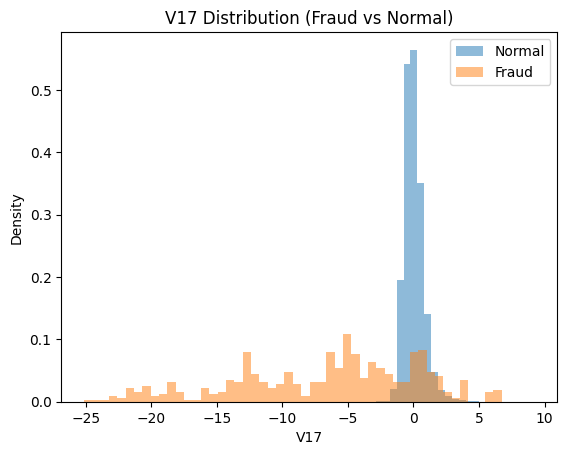

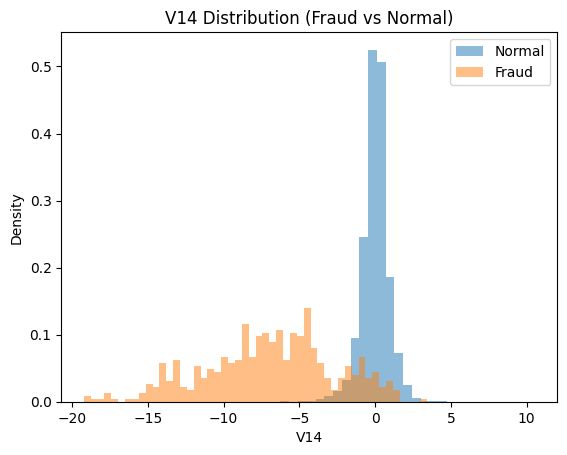

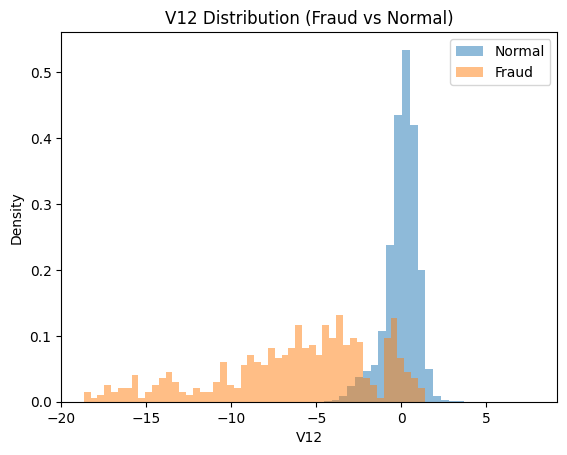

In [55]:
import matplotlib.pyplot as plt

features = ["V17", "V14", "V12"]

for feature in features:
    plt.figure()

    plt.hist(normal[feature], bins=50, alpha=0.5, density=True, label="Normal")
    plt.hist(fraud[feature], bins=50, alpha=0.5, density=True, label="Fraud")

    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.title(f"{feature} Distribution (Fraud vs Normal)")
    plt.legend()

    plt.show()

### Box Plots

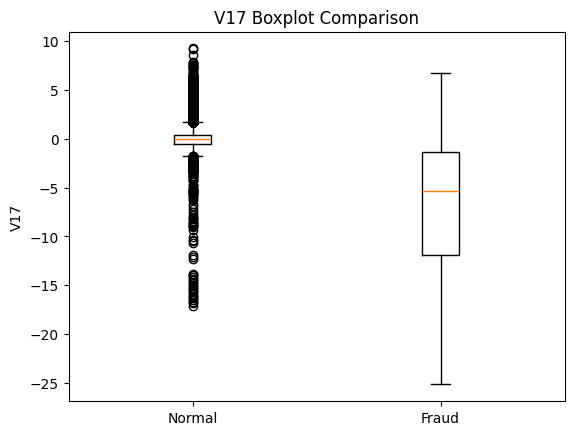

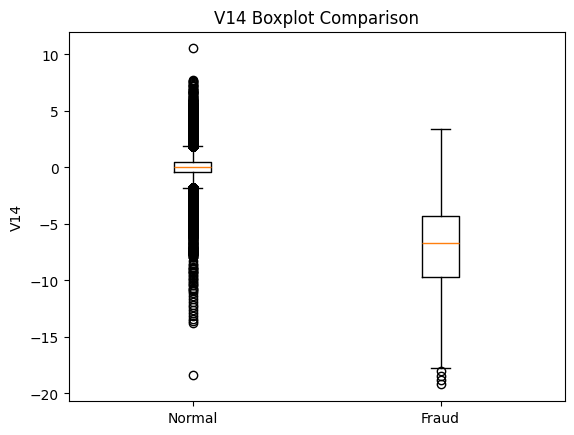

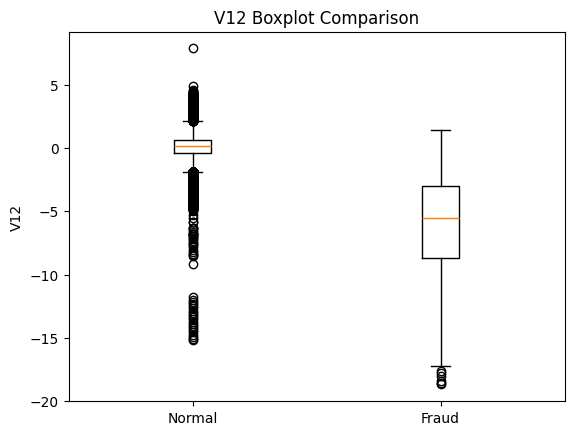

In [56]:
for feature in features:
    plt.figure()

    plt.boxplot(
        [normal[feature], fraud[feature]],
        tick_labels=["Normal", "Fraud"]
    )

    plt.title(f"{feature} Boxplot Comparison")
    plt.ylabel(feature)

    plt.show()

### PCA Feature Analysis (V17, V14, V12)

The selected PCA components (V17, V14, V12) exhibit clear structural differences between fraudulent and non-fraudulent transactions.

Normal transactions are tightly concentrated and approximately symmetric around zero, reflecting stable and consistent behavior in the transformed feature space. In contrast, fraudulent transactions display a broader and more dispersed distribution, often shifted toward negative values.

Histograms reveal that fraudulent transactions exhibit a multimodal structure, suggesting that fraud may arise from multiple underlying behavioral patterns rather than a single distribution.

Boxplot comparisons further highlight that fraudulent transactions have a significantly larger interquartile range, indicating greater variability. While normal transactions show many statistical outliers, this is largely attributable to their high sample size and tight central concentration.

Despite these differences, there remains substantial overlap between the two classes, indicating that no single feature is sufficient for perfect separation. This suggests that effective fraud detection will likely require combining multiple features in a multivariate model.